In [2]:
import igl
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh
from scipy.sparse import diags
from src.fatemarkers import FateMarkers
from src import utils 

from meshplot import plot, subplot 
from matplotlib import pyplot as plt

import vtk 
import time 

In [3]:
import importlib

import src.meshharm 
import src.fatemarkers
importlib.reload(src.meshharm)
importlib.reload(src.fatemarkers)
from src.fatemarkers import FateMarkers

### Load mesh and compute coefficients

In [4]:
path = 'Data/20250818/fractal_output/day4p5/r0.zarr/A/06/0_fused_zillum_registered/meshes/nnorg_linked_multi_annotated/18.vtp'
m = FateMarkers()

# loads all the results inc fate markers 
m.load_mesh_from_file(path) 

In [6]:
### Compute the mesh and some cofficients 
m.align_with_pca() 
_ = m.compute_coefficients(lmax=15) 

### Check reconstruction quality for a series of lmax values

maximumm l index: 15


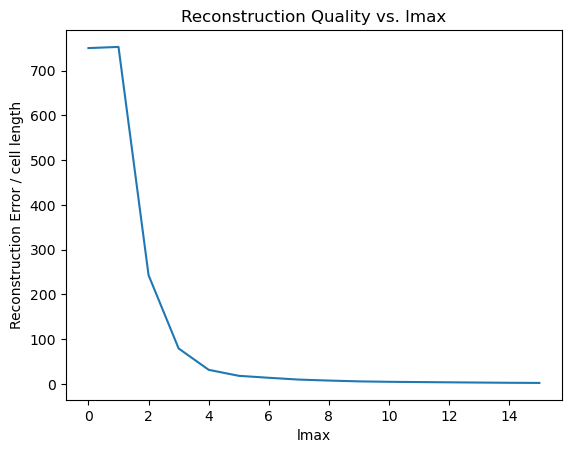

In [7]:
print('maximumm l index:', m.lmax)

errs = [] 
for l in range(m.lmax + 1):
    err = m.compute_recon_quality(lmax=l)
    errs.append(err)    

plt.plot(np.arange(len(errs)), errs)
plt.xlabel('lmax')
plt.ylabel('Reconstruction Error / cell length')
plt.title('Reconstruction Quality vs. lmax')
plt.show() 

### Compute HKS for a series of times (time ~ distance^2)

In [8]:
ts = [1, 4, 25, 100]
hks = m.compute_hks_for_new_times(ts, coeffs=False)

print(hks.shape) # fields associated with each vertex 
print(m.v.shape) 

(18001, 4)
(18001, 3)


In [9]:
plot(m.v, m.f, c=hks[:, 0])

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1176834…

### Visualise the encoding using bag of features

In [10]:
# loads the vocab from file 
res = np.load('sim/vocab.npz', allow_pickle=True)
vocab = res['vocab']
scaler = res['scalar'].item() 
sigma = res['sigma']
ts = res['ts']

hks = m.compute_hks_for_new_times(ts, coeffs=False)

In [11]:
hks_scaled = scaler.transform(hks)
dist = np.linalg.norm(hks_scaled[:, np.newaxis, :]- vocab[np.newaxis, :, :], axis=2)
encoding = np.exp(-dist**2 / (2 * sigma**2))

In [12]:
for i in range(encoding.shape[1]):
    print(np.min(encoding[:, i]), np.max(encoding[:, i]))
    plot(m.v, m.f, c=encoding[:, i])

1.2080335e-18 0.003783732


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1176834…

0.0 0.0


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1176834…

1.5017143e-10 0.6122589


...

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1176834…

0.0 0.0


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1176834…

5.1314663e-07 0.9858507


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1176834…

### Visualise the reconstructed fate markers

In [ ]:
recon_field = m.eigvecs[:, :int(m.lmax**2)] @ m.coeffs_fm[:int(m.lmax**2), ]

for (i, name) in enumerate(m.field_names):
    if i in [1, 2]:
        print(name)
        print(np.min(recon_field[:, i]), np.max(recon_field[:, i]))
        plot(m.v, m.f, c=m.fields[:, i]) # note that this doesn't work if we load mesh results directly 
        plot(m.v, m.f, c=recon_field[:, i])

4.C01.mean_intensity
6066.079239447563 14730.31585088444


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1176834…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1176834…

4.C01.percentile95
9288.919408850641 21358.354347514265


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1176834…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1176834…